In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

In [2]:
df=pd.read_csv("C:\\Users\\Reetesh\\Desktop\\Timeseries Forecasting project\\gpt\\store_sales_1.csv")
df.head()

,date,store_id,sales,promotion_flag,holiday_flag
0,01-01-2022,1,184.78,0,0
1,02-01-2022,1,192.62,0,0
2,03-01-2022,1,212.68,0,0
3,04-01-2022,1,249.58,1,0
4,05-01-2022,1,223.50,0,0


In [26]:
print("Rows:", len(df))
print("Date range:", df["date"].min().date(), "to", df["date"].max().date())
print("Stores:", df["store_id"].nunique())
df.describe()

Rows: 7300
Date range: 2022-01-01 to 2023-12-31
Stores: 10


,date,store_id,sales,promotion_flag,holiday_flag,promotion
count,7300,7300.000000,7300.000000,7300.000000,7300.000000,7300.000000
mean,2022-12-31 12:00:00,5.500000,228.434571,0.202192,0.104110,0.202192
min,2022-01-01 00:00:00,1.000000,160.710000,0.000000,0.000000,0.000000
25%,2022-07-02 00:00:00,3.000000,209.217500,0.000000,0.000000,0.000000
50%,2022-12-31 12:00:00,5.500000,226.795000,0.000000,0.000000,0.000000
75%,2023-07-02 00:00:00,8.000000,245.590000,0.000000,0.000000,0.000000
max,2023-12-31 00:00:00,10.000000,340.730000,1.000000,1.000000,1.000000
std,NaN,2.872478,26.625636,0.401662,0.305424,0.401662


In [3]:
print("Missing values per column:")
print(df.isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Missing values per column:
date              0
store_id          0
sales             0
promotion_flag    0
holiday_flag      0
dtype: int64

Duplicate rows: 0


In [ ]:
# Parse date, sort, enforce dtypes

df["date"] = pd.to_datetime(df["date"], dayfirst=True, errors="coerce")
df["store_id"] = df["store_id"].astype(int)
df["promotion"] = df["promotion_flag"].astype(int)
df["holiday_flag"] = df["holiday_flag"].astype(int)
df = df.sort_values(["store_id", "date"]).reset_index(drop=True)

print("Date range:", df["date"].min(), "to", df["date"].max())
print("Number of stores:", df["store_id"].nunique())
print("Total rows:", len(df))
df.describe(include="all").T

Date range: 2022-01-01 00:00:00 to 2023-12-31 00:00:00
Number of stores: 10
Total rows: 7300


,count,mean,min,25%,50%,75%,max,std
date,7300,2022-12-31 12:00:00,2022-01-01 00:00:00,2022-07-02 00:00:00,2022-12-31 12:00:00,2023-07-02 00:00:00,2023-12-31 00:00:00,NaN
store_id,7300.0,5.5,1.0,3.0,5.5,8.0,10.0,2.872478
sales,7300.0,228.434571,160.71,209.2175,226.795,245.59,340.73,26.625636
promotion_flag,7300.0,0.202192,0.0,0.0,0.0,0.0,1.0,0.401662
holiday_flag,7300.0,0.10411,0.0,0.0,0.0,0.0,1.0,0.305424
promotion,7300.0,0.202192,0.0,0.0,0.0,0.0,1.0,0.401662


In [6]:
# Check for missing dates per store (gaps in the time series)
for i in sorted(df["store_id"].unique()):
    sub = df[df["store_id"] == i]
    full_range = pd.date_range(sub["date"].min(), sub["date"].max(), freq="D")
    missing_dates = full_range.difference(sub["date"])
    print(f"Store {i}: {len(missing_dates)} missing calendar day(s) out of {len(full_range)}")


Store 1: 0 missing calendar day(s) out of 730
Store 2: 0 missing calendar day(s) out of 730
Store 3: 0 missing calendar day(s) out of 730
Store 4: 0 missing calendar day(s) out of 730
Store 5: 0 missing calendar day(s) out of 730
Store 6: 0 missing calendar day(s) out of 730
Store 7: 0 missing calendar day(s) out of 730
Store 8: 0 missing calendar day(s) out of 730
Store 9: 0 missing calendar day(s) out of 730
Store 10: 0 missing calendar day(s) out of 730


C:\Users\Reetesh\AppData\Local\Temp\ipykernel_22352\3525153121.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="store_id", y="sales", palette="Set3")


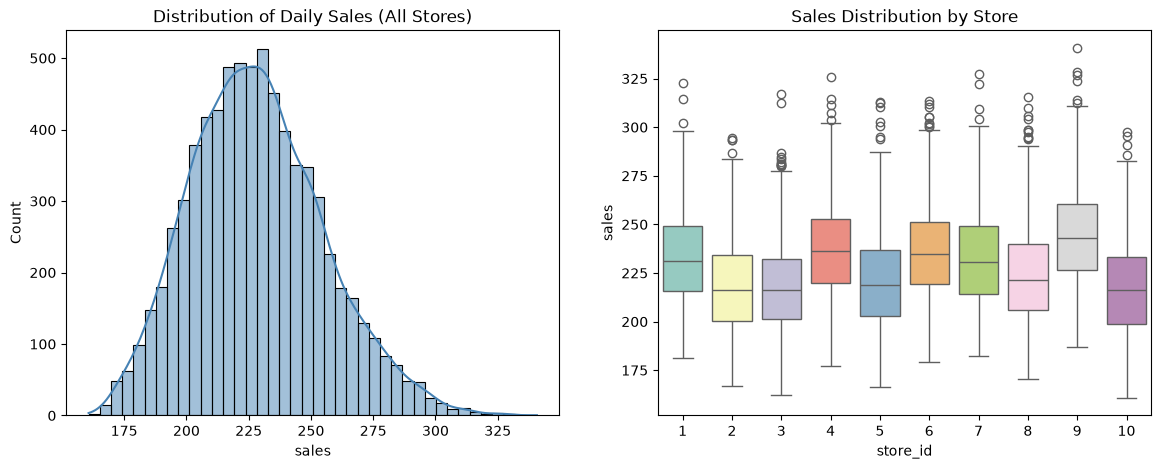

count    7300.000000
mean      228.434571
std        26.625636
min       160.710000
25%       209.217500
50%       226.795000
75%       245.590000
max       340.730000
Name: sales, dtype: float64
Skewness: 0.382 | Kurtosis: 0.020


In [12]:
# 3. Univariate EDA — Sales Distribution

#sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 5))

# Left plot: Histogram
plt.subplot(1, 2, 1)
sns.histplot(data=df, x="sales", kde=True, bins=40, color="steelblue")
plt.title("Distribution of Daily Sales (All Stores)")

# Right plot: Boxplot
plt.subplot(1, 2, 2)
sns.boxplot(data=df, x="store_id", y="sales", palette="Set3")
plt.title("Sales Distribution by Store")

#plt.tight_layout()
plt.show()

# 2. Summary Statistics
print(df["sales"].describe())
print(f"Skewness: {df['sales'].skew():.3f} | Kurtosis: {df['sales'].kurt():.3f}")

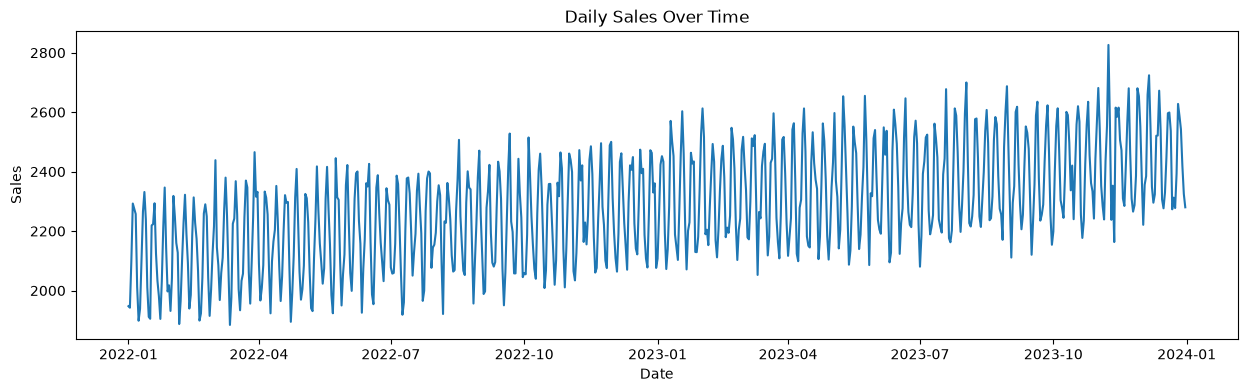

In [22]:
#  Overall Sales Trend Over Time

daily_sales = df.groupby("date")["sales"].sum()

plt.figure(figsize=(15, 4))

plt.plot(daily_sales.index, daily_sales.values)
plt.title("Daily Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

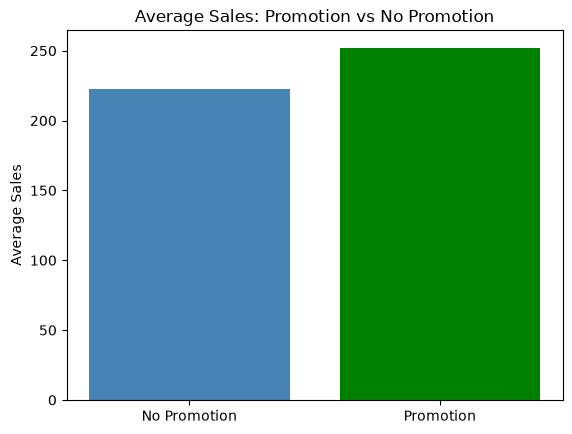

Average sales with promotion: 251.97
Average sales without promotion: 222.47
Promotion lift: 13.3%


In [38]:
#Promotion-Based Inferences & Trends

promo_avg = df.groupby("promotion_flag")["sales"].mean()

plt.bar(["No Promotion", "Promotion"], promo_avg.values, color=["steelblue", "green"])
plt.title("Average Sales: Promotion vs No Promotion")
plt.ylabel("Average Sales")
plt.show() 

promo_lift = (promo_avg[1] / promo_avg[0] - 1) * 100
print(f"Average sales with promotion: {promo_avg[1]:.2f}")
print(f"Average sales without promotion: {promo_avg[0]:.2f}")
print(f"Promotion lift: {promo_lift:.1f}%")


**Finding:** Promotions increase average sales relative to normal days (see lift % above).
This confirms promotions are an effective, repeatable lever for boosting short-term sales.

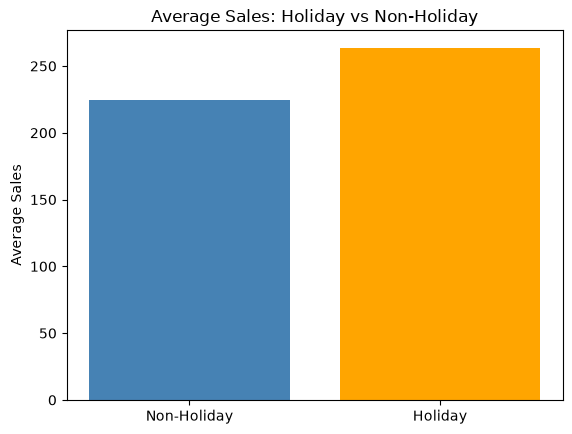

Average sales on holidays: 263.52
Average sales on non-holidays: 224.36
Holiday lift: 17.5%


In [39]:
#Holiday-Based Inferences & Trends

holiday_avg = df.groupby("holiday_flag")["sales"].mean()

plt.bar(["Non-Holiday", "Holiday"], holiday_avg.values, color=["steelblue", "orange"])
plt.title("Average Sales: Holiday vs Non-Holiday")
plt.ylabel("Average Sales")
plt.show()

holiday_lift = (holiday_avg[1] / holiday_avg[0] - 1) * 100
print(f"Average sales on holidays: {holiday_avg[1]:.2f}")
print(f"Average sales on non-holidays: {holiday_avg[0]:.2f}")
print(f"Holiday lift: {holiday_lift:.1f}%")



**Finding:** Holidays show a noticeably higher average sales figure than regular days
(see lift % above). This suggests holidays reliably drive extra demand and should be planned
for with adequate stock and staffing.

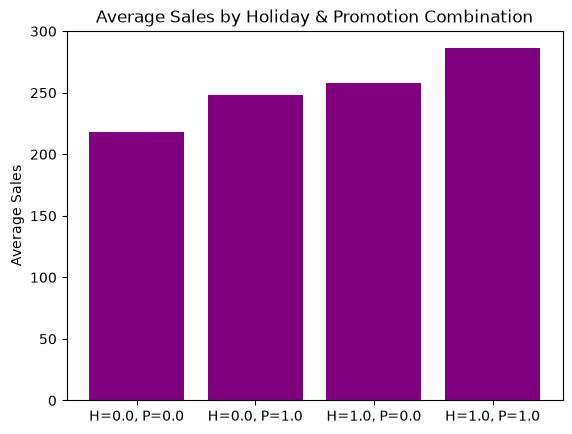

,label,sales
0,"H=0.0, P=0.0",218.327542
1,"H=0.0, P=1.0",248.090694
2,"H=1.0, P=0.0",257.933941
3,"H=1.0, P=1.0",286.041722


In [45]:
## Holiday + Promotion Together

combo_avg = df.groupby(["holiday_flag", "promotion_flag"])["sales"].mean().reset_index()
combo_avg["label"] = combo_avg.apply(lambda r: f"H={r.holiday_flag}, P={r.promotion_flag}", axis=1)

plt.bar(combo_avg["label"], combo_avg["sales"], color="purple")
plt.title("Average Sales by Holiday & Promotion Combination")
plt.ylabel("Average Sales")
plt.show()

combo_avg[["label", "sales"]]

**Finding:** Compare the "H=1, P=1" bar to the others above — if it is the highest bar,
running a promotion *during* a holiday compounds the lift rather than just replacing it.

<Figure size 500x5000 with 0 Axes>

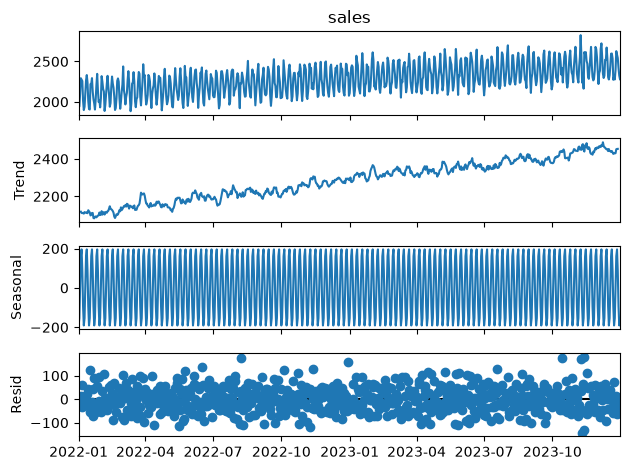

In [61]:
from statsmodels.tsa.seasonal import seasonal_decompose

ts = daily_sales.asfreq("D").interpolate()

plt.figure(figsize=(5, 50))
result = seasonal_decompose(ts, model="additive", period=7)
result.plot()
plt.show()


In [48]:
trend_start = result.trend.dropna().iloc[0]
trend_end = result.trend.dropna().iloc[-1]
trend_change = trend_end - trend_start

seasonal_range = result.seasonal.max() - result.seasonal.min()
residual_std = result.resid.std()

print(f"Trend moved from {trend_start:.1f} to {trend_end:.1f} (change: {trend_change:+.1f})")
print(f"Seasonal swing (weekly pattern): {seasonal_range:.1f}")
print(f"Residual (noise) std dev: {residual_std:.1f}")


Trend moved from 2118.1 to 2453.7 (change: +335.6)
Seasonal swing (weekly pattern): 386.4
Residual (noise) std dev: 51.6


**Findings:**
- **Trend:** The trend line above overall sales are rising.
- **Seasonality:** A repeating 7-day (weekly) pattern is visible in the seasonal component —
  some days of the week consistently sell more than others.
- **Residual:** The leftover noise after removing trend and seasonality should look random with
  no visible pattern; its size (std dev above) reflects day-to-day unpredictability not explained
  by trend, weekly pattern, holidays, or promotions.


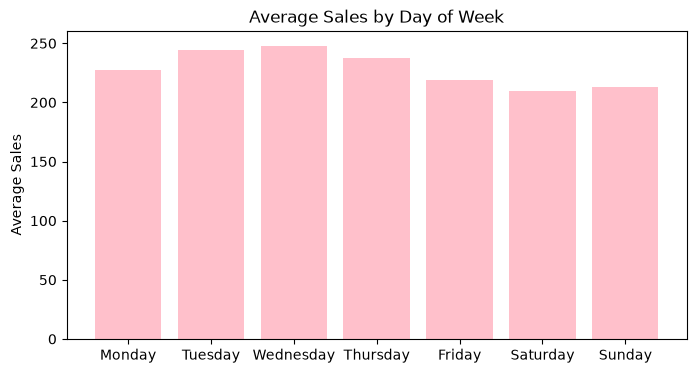

Best day: Wednesday (248.05 avg sales)
Worst day: Saturday (209.46 avg sales)


In [53]:
df["day_of_week"] = df["date"].dt.day_name()

dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

dow_avg = df.groupby("day_of_week")["sales"].mean().reindex(dow_order)

plt.figure(figsize=(8,4))
plt.bar(dow_avg.index, dow_avg.values, color="pink")
plt.title("Average Sales by Day of Week")
plt.ylabel("Average Sales")
plt.show()

best_day = dow_avg.idxmax()
worst_day = dow_avg.idxmin()
print(f"Best day: {best_day} ({dow_avg.max():.2f} avg sales)")
print(f"Worst day: {worst_day} ({dow_avg.min():.2f} avg sales)")



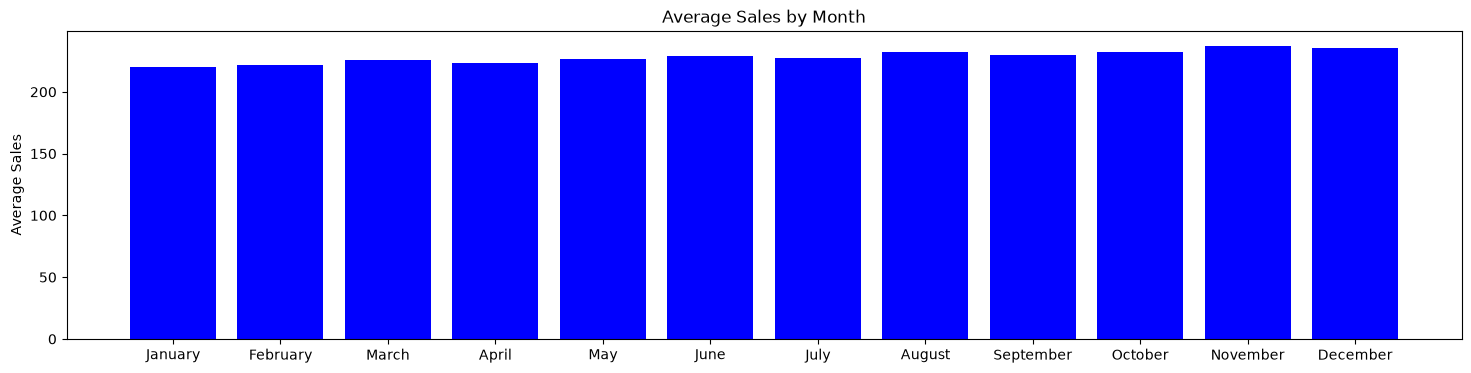

Best day: November (237.41 avg sales)
Worst day: January (220.01 avg sales)


In [54]:
df["month"] = df["date"].dt.month_name()

month_order = ["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November", "December"]

month_avg = df.groupby("month")["sales"].mean().reindex(month_order)

plt.figure(figsize=(18,4))

plt.bar(month_avg.index, month_avg.values, color="blue")
plt.title("Average Sales by Month")
plt.ylabel("Average Sales")
plt.show()

best_month = month_avg.idxmax()
worst_month = month_avg.idxmin()
print(f"Best day: {best_month} ({month_avg.max():.2f} avg sales)")
print(f"Worst day: {worst_month} ({month_avg.min():.2f} avg sales)")

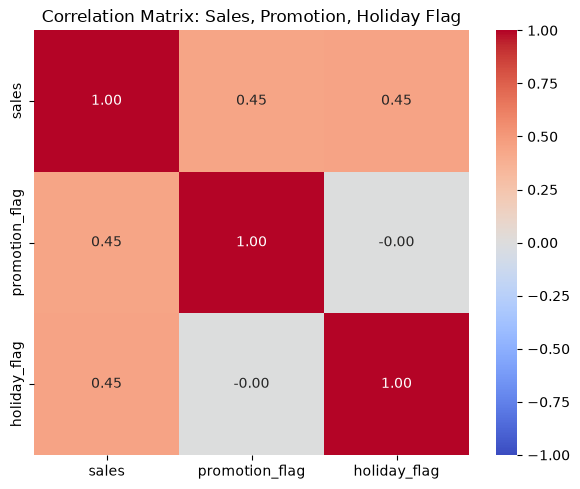

,sales,promotion_flag,holiday_flag
sales,1.000000,0.445086,0.449217
promotion_flag,0.445086,1.000000,-0.002977
holiday_flag,0.449217,-0.002977,1.000000


In [58]:
corr_df = df[["sales", "promotion_flag", "holiday_flag"]].copy()
corr_matrix = corr_df.corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f")
plt.title("Correlation Matrix: Sales, Promotion, Holiday Flag")
plt.tight_layout()
plt.show()

display(corr_matrix)